# Install Software

In [1]:
!pip install pymannkendall
!pip install matplotlib-scalebar

# Import 

In [2]:
import os
import re
import itertools
import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import datetime
import glob
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
import matplotlib.patches as mpatches
from statsmodels.tsa.seasonal import seasonal_decompose
from datacube.utils.geometry import Geometry, CRS
from matplotlib.colors import Normalize
from matplotlib_scalebar.scalebar import ScaleBar
from datacube import Datacube
import datacube
import dea_tools.datahandling
import dea_tools.bandindices
from pymannkendall.pymannkendall import (
    __preprocessing,
    __missing_values_analysis,
    __mk_score,
    __variance_s,
    __z_score,
    __p_value,
    sens_slope,
)


# Parameters to change
An output of the WIT tool is a csv file which we will use to detect change at the site. Add the file name into the line that says "ACTION". The 'date' column will be converted so it is able to be read for time series operations such as plotting and ordered into chronological order. 

In [3]:

csv_path = "178.csv"              # ACTION: Add CSV output from WIT tool (This is from DEA Maps)
component = "PV"                   # CHANGE THIS to the component you want to analyze (e.g. "PV", "GV", "NPV", "WET", "WATER")
polygon_path = "ginini_flats.shp"  # ACTION: change this if your polygon file has another name
time_window_days = 15              # how many days before/after to search for imagery

# Create output folder for validation images
out_folder = "validation_images"
os.makedirs(out_folder, exist_ok=True)


# Initialise Datacube Connection

In [4]:
dc = Datacube(app="change_detection_validation")
df = pd.read_csv(csv_path)
df["TIME"] = pd.to_datetime(df["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)


# Edit out low quality data

In [5]:
def generate_low_quality_data_periods(df):
    """
    Mark periods with low-quality data:
    - Landsat 5-8 SLC-off gap (Nov 2011 - Apr 2013)
    - Low observation density (less than 4 observations in 365 days)
    """
    df = df.copy()
    df["off_value"] = 0
    
    # Landsat 5-8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100
    
    # Low observation density (less than 4 in 365 days)
    # Sort by time to ensure proper sequential checking
    df_sorted = df.sort_values('TIME').reset_index(drop=True)
    for i in range(len(df_sorted) - 3):
        if (df_sorted.loc[i + 3, "TIME"] - df_sorted.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df_sorted.loc[i, "TIME"])
                & (df["TIME"] <= df_sorted.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100
    return df

df = generate_low_quality_data_periods(df)

if component not in df.columns:
    raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")


# Create low quality ranges - groups low quality consecutive periods and records the start and end dates

low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

# Smooth data

pv = df.set_index("TIME")[component].astype(float)
pv = pv.resample('MS').mean().interpolate(method='cubic')  # Smooth monthly data using MS and interpolates the missing months with cubic interpolation


# Time series decomposition and change detection

Seasonal decomposition

In [6]:
# Remove large temporal gaps larger than 60 days (~ 2 months)
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

if len(pv_filtered) < 24:
    print(f"Not enough data for {component}, skipping.")
else:
    # Decompose time series into trend, seasonal and residual using an additive model over a 12 month period. 
    result = seasonal_decompose(pv_filtered, model="additive", period=12)
    trend = result.trend
    seasonal = result.seasonal
    resid = result.resid

    # Detect abrupt changes when anything beyond the below number of standard deviations is flagged as an abrupt change.
    threshold = 2 * resid.std()                                  #ACTION: Adjust threshold for more sensitive change detection (2 is the default as it follows the 2-sigma rule)
    change_points = resid[abs(resid) > threshold].index
    change_points_sorted = sorted(change_points)
    print(f"Detected {len(change_points_sorted)} abrupt change points in {component} residuals.")

  

Detected 23 abrupt change points in PV residuals.


 # PLOT: Time Series Decomposition

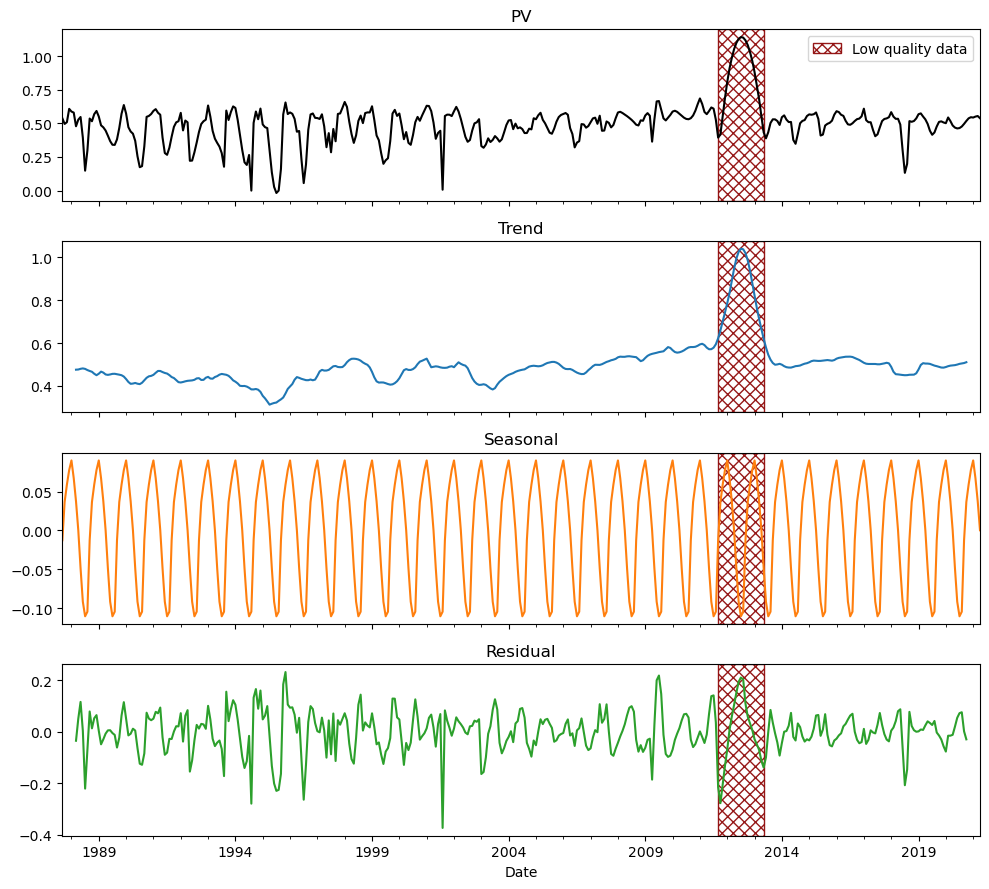

In [7]:

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

pv.plot(ax=axes[0], title=f"{component}", color="black")
trend.plot(ax=axes[1], title="Trend", color="tab:blue")
seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
resid.plot(ax=axes[3], title="Residual", color="tab:green")

    # Shade low-quality data
for ax in axes:
    for start, end in low_quality_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="darkred", 
                    hatch="xxx", alpha=0.9)

# Add legend for low-quality data 
low_quality_patch = mpatches.Patch(
    facecolor="none", edgecolor="darkred", hatch="xxx", label="Low quality data", alpha=0.9
)

# Add the legend to just the top plot (or whichever you want)
axes[0].legend(handles=[low_quality_patch], loc="upper right", frameon=True)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# PLOT: Time Series Decomposition with Change detection lines and ID

Low-quality range: 2011-09-11 to 2013-05-20

Before low-quality filtering: 16 change points
  - 1988-07-01
  - 1993-08-01
  - 1994-08-01
  - 1994-10-01
  - 1995-06-01
  - 1995-11-01
  - 1996-07-01
  - 2001-08-01
  - 2003-01-01
  - 2009-04-01
  - 2009-07-01
  - 2011-09-01
  - 2011-11-01
  - 2012-06-01
  - 2012-08-01
  - 2018-07-01
  REMOVED (low-quality): 2011-09-01
  REMOVED (low-quality): 2011-11-01
  REMOVED (low-quality): 2012-06-01
  REMOVED (low-quality): 2012-08-01

Final change points: 12
  1. 1988-07-01
  2. 1993-08-01
  3. 1994-08-01
  4. 1994-10-01
  5. 1995-06-01
  6. 1995-11-01
  7. 1996-07-01
  8. 2001-08-01
  9. 2003-01-01
  10. 2009-04-01
  11. 2009-07-01
  12. 2018-07-01

Threshold: 0.1612 (2 × std = 0.0806)


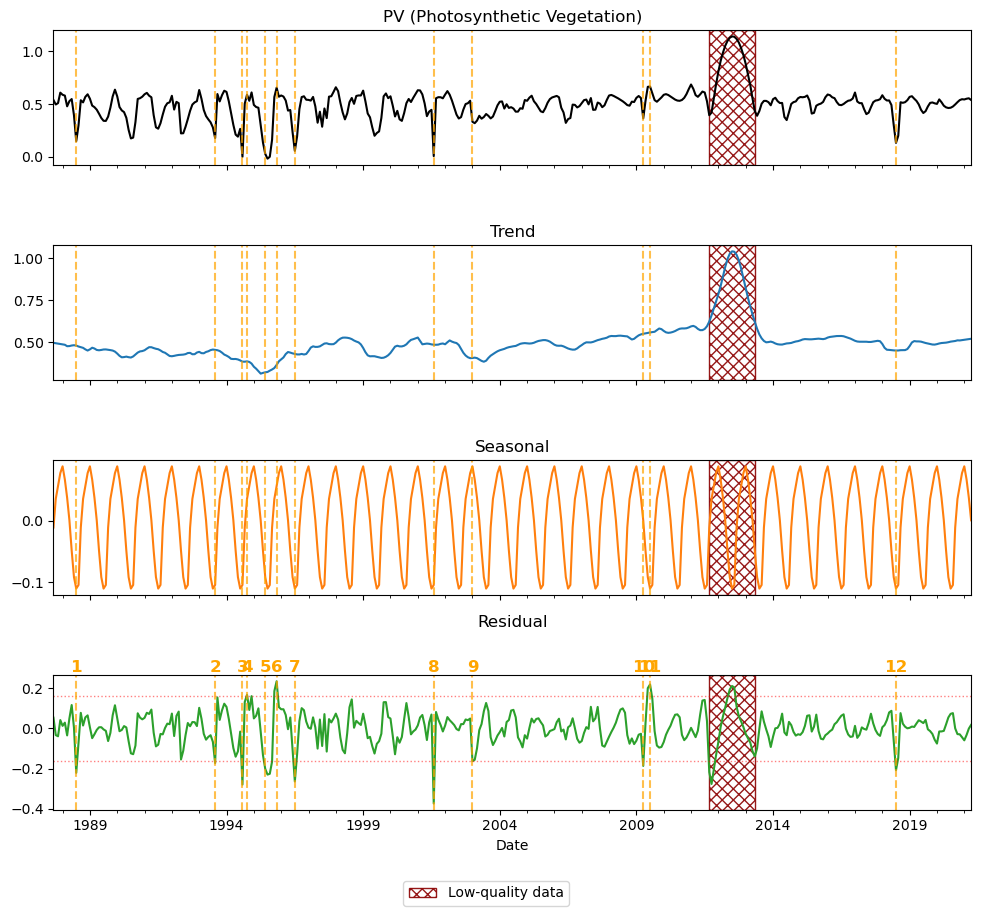

In [8]:
import datetime
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def generate_low_quality_data_periods(df):
    """
    Mark periods with low-quality data:
    - Landsat 5-8 SLC-off gap (Nov 2011 - Apr 2013)
    - Low observation density (less than 4 observations in 365 days)
    """
    df = df.copy()
    df["off_value"] = 0
    
    # Landsat 5-8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100
    
    # Low observation density (less than 4 in 365 days)
    df_sorted = df.sort_values('TIME').reset_index(drop=True)
    for i in range(len(df_sorted) - 3):
        if (df_sorted.loc[i + 3, "TIME"] - df_sorted.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df_sorted.loc[i, "TIME"])
                & (df["TIME"] <= df_sorted.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100
    return df

def is_in_low_quality_range_strict(date, low_quality_ranges):
    """
    Strictly check if a date falls within low-quality range, including boundaries.
    """
    for start, end in low_quality_ranges:
        # Check if date is within or very close to the range (within 1 month)
        buffer = pd.Timedelta(days=31)
        if (start - buffer) <= date <= (end + buffer):
            return True
    return False

def identify_steep_slope_regions(resid, threshold_multiplier=2.0, slope_window_months=3):
    """
    Identify regions where residuals are changing rapidly (steep slopes).
    Returns start and end dates of steep slope regions.
    """
    resid_clean = resid.dropna()
    if len(resid_clean) < 12:
        return []
    
    threshold = threshold_multiplier * resid_clean.std()
    
    # Find all points exceeding threshold
    exceeds_threshold = abs(resid_clean) > threshold
    candidate_dates = resid_clean.index[exceeds_threshold].tolist()
    
    if len(candidate_dates) < 2:
        return candidate_dates
    
    # Group consecutive points that are close together (within slope_window_months)
    slope_regions = []
    current_region = [candidate_dates[0]]
    
    for i in range(1, len(candidate_dates)):
        days_diff = (candidate_dates[i] - candidate_dates[i-1]).days
        if days_diff < slope_window_months * 30:  # Within the window
            current_region.append(candidate_dates[i])
        else:
            # End of current region
            if len(current_region) >= 2:
                # This is a steep slope region - keep only start and end
                slope_regions.append((current_region[0], current_region[-1]))
            else:
                # Single point, not a slope - keep it as is
                slope_regions.append((current_region[0], current_region[0]))
            current_region = [candidate_dates[i]]
    
    # Handle last region
    if len(current_region) >= 2:
        slope_regions.append((current_region[0], current_region[-1]))
    else:
        slope_regions.append((current_region[0], current_region[0]))
    
    # Extract change points: start and end of each region, or single points
    change_points = []
    for start, end in slope_regions:
        if start == end:
            # Single point
            change_points.append(start)
        else:
            # Steep slope region - keep only start and end
            change_points.append(start)
            # Only add end if it's significantly separated from start (at least 2 months)
            if (end - start).days >= 60:
                change_points.append(end)
            # Otherwise just keep the start
    return sorted(set(change_points))

# Validate component exists
if component not in df.columns:
    raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")

# Ensure TIME is datetime type
if not pd.api.types.is_datetime64_any_dtype(df['TIME']):
    df['TIME'] = pd.to_datetime(df['TIME'])

# Mark low-quality data periods
df = generate_low_quality_data_periods(df)

# Create low quality ranges
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))
        print(f"Low-quality range: {start.date()} to {end.date()}")

# Prepare data
pv = df.set_index("TIME")[component].astype(float)

# Smooth data BEFORE decomposition
pv_smooth = pv.resample('MS').mean().interpolate(method='cubic')

# Filter large gaps (>60 days)
gaps = pv_smooth.index.to_series().diff().dt.days
pv_filtered = pv_smooth.loc[gaps.fillna(1) < 60]

# Check if we have enough data
if len(pv_filtered) < 24:
    print(f"Not enough data for {component}, skipping.")
else:
    # Decompose time series using smoothed, filtered data
    result = seasonal_decompose(
        pv_filtered, 
        model="additive", 
        period=12,
        extrapolate_trend='freq'
    )
    
    trend = result.trend
    seasonal = result.seasonal
    resid = result.resid.dropna()
    
    # Identify steep slope regions (this handles clustering automatically)
    change_points_detected = identify_steep_slope_regions(
        resid, 
        threshold_multiplier=2.0,
        slope_window_months=4  # Points within 4 months are considered part of same slope
    )
    
    print(f"\nBefore low-quality filtering: {len(change_points_detected)} change points")
    for cp in change_points_detected:
        print(f"  - {cp.date()}")
    
    # STRICTLY filter out change points in low-quality ranges
    change_points_filtered = []
    for cp in change_points_detected:
        if not is_in_low_quality_range_strict(cp, low_quality_ranges):
            change_points_filtered.append(cp)
        else:
            print(f"  REMOVED (low-quality): {cp.date()}")
    
    change_points_sorted = sorted(change_points_filtered)
    
    print(f"\nFinal change points: {len(change_points_sorted)}")
    for idx, cp in enumerate(change_points_sorted, start=1):
        print(f"  {idx}. {cp.date()}")
    print(f"\nThreshold: {2.0 * resid.std():.4f} (2 × std = {resid.std():.4f})")
    
    # Plot
    fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
    
    pv_filtered.plot(ax=axes[0], title=f"{component} (Photosynthetic Vegetation)", color="black")
    result.trend.plot(ax=axes[1], title="Trend", color="tab:blue")
    result.seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
    result.resid.plot(ax=axes[3], color="tab:green")
    axes[3].set_title("Residual", pad=35)
    
    # Show threshold lines
    threshold_val = 2.0 * resid.std()
    axes[3].axhline(y=threshold_val, color='r', linestyle=':', alpha=0.5, linewidth=1, label='±2σ threshold')
    axes[3].axhline(y=-threshold_val, color='r', linestyle=':', alpha=0.5, linewidth=1)
    
    # Label axes
    axes[-1].set_xlabel("Date")
    
    # Shade low-quality data
    low_quality_patch = mpatches.Patch(facecolor="none", edgecolor="darkred", 
                                       hatch="xxx", label="Low-quality data", alpha=0.9)
    
    for ax in axes:
        for start, end in low_quality_ranges:
            ax.axvspan(start, end, facecolor="none", edgecolor="darkred", 
                       hatch="xxx", alpha=0.9)
    
    # Mark and label change points
    for idx, cp in enumerate(change_points_sorted, start=1):
        for ax in axes:
            ax.axvline(cp, color="orange", linestyle="--", alpha=0.7, linewidth=1.5)
        y_pos = result.resid.max() * 1.2 if result.resid.max() > 0 else result.resid.min() * 1.2
        axes[3].text(
            cp,
            y_pos,
            str(idx),
            color="orange",
            fontsize=12,
            fontweight="bold",
            ha="center",
            rotation=0,
            clip_on=False,
        )
    
    # Legend
    fig.legend(
        handles=[low_quality_patch],
        loc="lower center",
        ncol=1,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02)
    )
    
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()
    

# Export change points to csv

In [9]:
# EXPORT: Detected Change Points to CSV

change_data = pd.DataFrame({
    "Change_ID": range(1, len(change_points_sorted) + 1),
    "Timestamp": change_points_sorted
})
    
# Add component info and CSV path for context
change_data["Component"] = component
change_csv_path = csv_path.replace(".csv", f"_{component}_change_points.csv")
    
# Save to file
change_data.to_csv(change_csv_path, index=False)
print(f"Change point data saved to: {change_csv_path}")


Change point data saved to: 178_PV_change_points.csv


# Robust trends using Mann-Kendall Test with Slopes
Accounting for outliers, using Theil-Sen regression with Mann-Kendall significance

PV is increasing at 0.0023 per year on average (p-value: 0.0000)


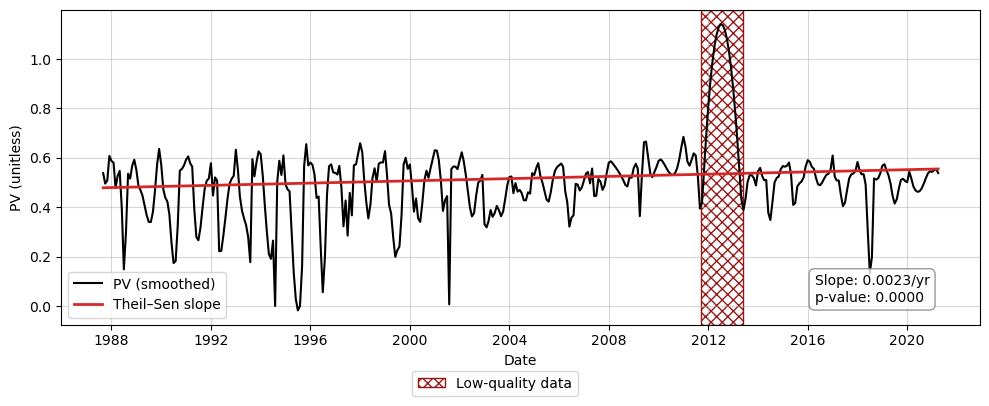

In [10]:
def mk_with_slopes(y, alpha=0.05):
    """
    Mann-Kendall test (Mann 1945, Kendall 1975, Gilbert 1987)
    Returns p-value, slope, and intercept.
    """
    res = namedtuple('Mann_Kendall_Test', ['p', 'slope', 'intercept'])

    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method='skip')
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    slope, intercept = sens_slope(y)

    return res(p, slope, intercept)

# Smooth component after analysis (cubic monthly interpolation)
component = "PV"
df["TIME"] = pd.to_datetime(df["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)

# Smooth PV time series for plotting
smoothed = df.set_index("TIME")[component].resample("MS").mean().interpolate(method="cubic")

# Run Mann–Kendall and Theil–Sen slope
mk_result = mk_with_slopes(smoothed)
p = mk_result.p
slope = mk_result.slope
intercept = mk_result.intercept

# Calculate per-year slope (slope is per month, so multiply by 12)
slope_per_year = slope * 12

# Print trend comment before plotting
if slope > 0:
    print(f"{component} is increasing at {slope_per_year:.4f} per year on average (p-value: {p:.4f})")
elif slope < 0:
    print(f"{component} is decreasing at {abs(slope_per_year):.4f} per year on average (p-value: {p:.4f})")
else:
    print(f"{component} shows no trend (slope: {slope_per_year:.4f} per year, p-value: {p:.4f})")

# Prepare Theil–Sen regression line
x_num = date2num(smoothed.index)
y_line = np.arange(len(smoothed)) * slope + intercept

# Plot smoothed data + Theil–Sen line + low-quality shading
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# Smoothed data
ax.plot(smoothed.index, smoothed, color="black", label=f"{component} (smoothed)")

# Theil–Sen slope line
ax.plot(smoothed.index, y_line, color="tab:red", linewidth=2, label="Theil–Sen slope")

# Shade low-quality data
low_quality_patch = mpatches.Patch(facecolor="none", edgecolor="darkred", 
                                   hatch="xxx", label="Low-quality data", alpha=0.9)

for start, end in low_quality_ranges:
    ax.axvspan(start, end, facecolor="none", edgecolor="darkred", hatch="xxx", alpha=0.9)

# Annotate slope and p-value
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Final layout and styling
ax.set_ylabel(f"{component} (unitless)")
ax.set_xlabel("Date")
ax.grid(alpha=0.5)

# Legend below plot
fig.legend(
    handles=[low_quality_patch],
    loc="lower center",
    ncol=1,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02)
)

ax.legend(loc='lower left', frameon=True)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

# Validation imagery

In [13]:
# ============================================
# FUNCTION: Find Imagery for Change Point (SIMPLIFIED TIMEZONE HANDLING)
# ============================================
def find_imagery_for_change_point(change_timestamp, time_window_days=None, change_id=None, max_search_days=180):
    """
    Find and load the nearest available satellite imagery (before, at, and after) for a change point.
    Uses ARD (Analysis Ready Data) products: ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3
    """
    # Load polygon
    poly = gpd.read_file(polygon_path)
    if poly.crs != CRS("EPSG:3577"):
        poly = poly.to_crs("EPSG:3577")
    
    poly_geom = Geometry(poly.geometry.iloc[0], CRS("EPSG:3577"))
    
    # Convert to pandas Timestamp (handles timezone automatically)
    change_date = pd.Timestamp(change_timestamp)
    # Remove timezone for query (datacube handles this internally)
    if change_date.tz is not None:
        change_date = change_date.tz_localize(None)
    
    # Correct ARD product names
    all_products = [
        'ga_ls5t_ard_3',   # Landsat 5 ARD (1987-2011)
        'ga_ls7e_ard_3',   # Landsat 7 Enhanced ARD (2003+)
        'ga_ls8c_ard_3',   # Landsat 8 ARD (2013+)
    ]
    
    def find_nearest_imagery(target_date, label, search_before=True, change_id=None, max_days=max_search_days):
        """Find nearest available imagery, checking all ARD products."""
        # Ensure target_date is pandas Timestamp, no timezone
        target_date = pd.Timestamp(target_date)
        if target_date.tz is not None:
            target_date = target_date.tz_localize(None)
        
        if search_before:
            time_start = target_date - pd.Timedelta(days=max_days)
            time_end = target_date - pd.Timedelta(days=1)
        else:
            time_start = target_date + pd.Timedelta(days=1)
            time_end = target_date + pd.Timedelta(days=max_days)
        
        best_dataset = None
        best_product = None
        best_date = None
        min_days_diff = float('inf')
        
        # First, find which products have data and get the closest dataset
        print(f"   Searching for {label} imagery in products: {', '.join(all_products)}")
        for product in all_products:
            try:
                # Check if product exists and has data
                datasets = dc.find_datasets(
                    product=product,
                    geopolygon=poly_geom,
                    time=(time_start, time_end)
                )
                dataset_list = list(datasets)
                
                if len(dataset_list) > 0:
                    print(f"   Found {len(dataset_list)} datasets in {product}")
                    # Find closest dataset to target date
                    for ds in dataset_list:
                        # Get dataset date and convert to pandas Timestamp
                        ds_time = ds.time.begin
                        ds_date = pd.Timestamp(ds_time)
                        # Remove timezone for comparison
                        if ds_date.tz is not None:
                            ds_date = ds_date.tz_localize(None)
                        
                        # Calculate days difference
                        days_diff = abs((ds_date - target_date).days)
                        if days_diff < min_days_diff:
                            min_days_diff = days_diff
                            best_dataset = ds
                            best_product = product
                            best_date = ds_date
                            
            except ValueError:
                # Product doesn't exist or no data, skip
                continue
            except Exception as e:
                print(f"   Warning: Error checking {product}: {str(e)}")
                continue
        
        if best_dataset is None:
            print(f"   ⚠️ No imagery found for {label} period (searched {max_days} days {'before' if search_before else 'after'} {target_date.date()})")
            return None
        
        # Now load the data for the best dataset
        try:
            print(f"   ✅ Found {label} imagery: {best_product} (date: {best_date.date()}, {min_days_diff} days {'before' if search_before else 'after'} change point)")
            
            # Load the specific dataset using the date range around best_date
            query_start = best_date - pd.Timedelta(days=1)
            query_end = best_date + pd.Timedelta(days=1)
            
            query = {
                'geopolygon': poly_geom,
                'time': (query_start, query_end),
                'output_crs': 'EPSG:3577',
                'resolution': (-30, 30),
                'group_by': 'solar_day',
                'dask_chunks': {"time": 1, "x": 2048, "y": 2048},
            }
            
            ds = dc.load(
                product=best_product,
                measurements=['nbart_red', 'nbart_green', 'nbart_blue', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2'],
                **query
            )
            
            if len(ds.time) == 0:
                print(f"   ⚠️ Could not load data for {label} (dataset found but load failed)")
                return None
            
            # Select the time slice closest to best_date
            # Find the time slice closest to our target
            time_diffs = abs(pd.to_datetime(ds.time.values) - best_date)
            closest_time_idx = time_diffs.argmin()
            ds_selected = ds.isel(time=closest_time_idx).load()
            
            # Create filename - use date from the loaded dataset
            image_time = pd.to_datetime(ds_selected.time.values)
            image_date_str = pd.Timestamp(image_time).strftime('%Y%m%d')
            
            if change_id is not None:
                filename = f"change_{change_id}_{label}_{image_date_str}.nc"
            else:
                filename = f"{label}_{image_date_str}.nc"
            
            file_path = os.path.join(out_folder, filename)
            ds_selected.to_netcdf(file_path)
            print(f"   ✅ Saved {label} imagery: {filename}")
            
            return file_path
            
        except Exception as e:
            print(f"   ⚠️ Error loading {label} imagery: {str(e)}")
            import traceback
            traceback.print_exc()
            return None
    
    # Find imagery
    print(f"   Finding nearest available imagery for change point at {change_date.date()}...")
    print(f"   Maximum search window: {max_search_days} days")
    
    before_path = find_nearest_imagery(change_date, 'before', search_before=True, change_id=change_id, max_days=max_search_days)
    change_path = find_nearest_imagery(change_date, 'change', search_before=False, change_id=change_id, max_days=30)
    after_path = find_nearest_imagery(change_date, 'after', search_before=False, change_id=change_id, max_days=max_search_days)
    
    return before_path, change_path, after_path

change_id_to_validate = 10         # ACTION: which change ID from the graph/table

# ============================================
# VALIDATION: Generate Imagery for Selected Change Point
# ============================================
if len(change_points_sorted) > 0:
    # Get the change timestamp for the selected change ID
    selected_change_idx = change_id_to_validate - 1  # Convert to 0-based index
    
    if selected_change_idx < len(change_points_sorted):
        selected_change_timestamp = change_points_sorted[selected_change_idx]
        
        print(f"\n🔍 Generating validation imagery for Change ID {change_id_to_validate}")
        print(f"   Change date: {selected_change_timestamp.date()}")
        
        # Load polygon once for reuse
        poly = gpd.read_file(polygon_path)
        if poly.crs != CRS("EPSG:3577"):
            poly = poly.to_crs("EPSG:3577")
        
        before_path, change_path, after_path = find_imagery_for_change_point(
            selected_change_timestamp, 
            time_window_days=time_window_days,
            change_id=change_id_to_validate
        )
        
        # --- Helper functions ---
        def add_extent_padding(extent, padding_fraction=0.05):
            """
            Adds a proportional padding around the extent for better map framing.
            Extent format: [minx, maxx, miny, maxy]
            padding_fraction = % of total width/height to expand by
            """
            minx, maxx, miny, maxy = extent
            width = maxx - minx
            height = maxy - miny
            pad_x = width * padding_fraction
            pad_y = height * padding_fraction
            return [minx - pad_x, maxx + pad_x, miny - pad_y, maxy + pad_y]

        def add_scalebar(ax, pixel_size_m, length_m=10000, location="lower right",
                 box_color="white", box_alpha=0.8, pad=0.5):
            """
            Add a scale bar to the axis.
            - pixel_size_m: pixel size in metres (e.g. 30.0)
            - length_m: desired bar length in metres (e.g. 10000 for 10 km)
            - location: legend location
            """
            # Choose units and convert dx accordingly
            if length_m >= 1000 and (length_m % 1000 == 0):
                # Prefer km units where sensible (e.g., 10000 m -> 10 km)
                units = "km"
                fixed_value = length_m // 1000  # e.g., 10000 -> 10
                dx = pixel_size_m / 1000.0       # convert metres/pixel -> km/pixel
            else:
                units = "m"
                fixed_value = length_m
                dx = pixel_size_m               # metres/pixel
            
            scalebar = ScaleBar(dx,
                                units=units,
                                fixed_value=fixed_value,
                                location=location,
                                box_color=box_color,
                                box_alpha=box_alpha,
                                scale_loc="bottom",
                                pad=pad)
            ax.add_artist(scalebar)


        # ============================================
        # VALIDATION: Compare Before/After Imagery
        # ============================================
        if before_path is not None and after_path is not None:
            # Extract date info from filenames
            def extract_date_from_filename(path):
                match = re.search(r"\d{8}", path)
                return match.group(0) if match else "Unknown"
            
            before_date = extract_date_from_filename(before_path)
            after_date = extract_date_from_filename(after_path)
            
            print(f"\n   Using imagery dates:")
            print(f"   Before: {before_date}")
            print(f"   After: {after_date}")
            
            # Open datasets
            before_ds = xr.open_dataset(before_path)
            after_ds = xr.open_dataset(after_path)
            
            # Load CSV data to get component values for the dates (for context/validation)
            df_validation = pd.read_csv(csv_path)
            df_validation["TIME"] = pd.to_datetime(df_validation["TIME"])
            
            # Find closest dates in CSV to our imagery dates
            before_date_dt = pd.to_datetime(before_date, format='%Y%m%d')
            after_date_dt = pd.to_datetime(after_date, format='%Y%m%d')
            
            # Get component value for before date (closest match)
            before_idx = (df_validation["TIME"] - before_date_dt).abs().idxmin()
            before_component_value = df_validation.loc[before_idx, component] if component in df_validation.columns else None
            before_csv_date = df_validation.loc[before_idx, "TIME"]
            
            # Get component value for after date (closest match)
            after_idx = (df_validation["TIME"] - after_date_dt).abs().idxmin()
            after_component_value = df_validation.loc[after_idx, component] if component in df_validation.columns else None
            after_csv_date = df_validation.loc[after_idx, "TIME"]
            
            print(f"\n   Component values from CSV (aggregated for polygon):")
            if before_component_value is not None:
                print(f"   Before: {component} = {before_component_value:.4f} (date: {before_csv_date.date()})")
            if after_component_value is not None:
                print(f"   After: {component} = {after_component_value:.4f} (date: {after_csv_date.date()})")
            
            # Map component name to Fractional Cover measurement name (lowercase)
            component_to_fc_measurement = {
                "PV": "pv",
                "NPV": "npv", 
                "BS": "bs",
                "WET": "ue",  # Unconsolidated elements (wetness)
                "WATER": "ue"  # May need to check this mapping
            }
            
            fc_measurement = component_to_fc_measurement.get(component, component.lower())
            print(f"   Using Fractional Cover measurement: {fc_measurement}")
            
            # Get polygon bounds for query
            poly_bounds = poly.total_bounds  # [minx, miny, maxx, maxy]
            
            # Load polygon for geometry
            poly_geom = Geometry(poly.geometry.iloc[0], CRS("EPSG:3577"))
            
            # Get time ranges for FC loading
            before_time = pd.to_datetime(before_ds.time.values)
            after_time = pd.to_datetime(after_ds.time.values)
            
            print(f"   Loading Fractional Cover data...")
            
            # Load FC for before date using new approach
            before_query = {
                'geopolygon': poly_geom,
                'time': (before_time - pd.Timedelta(days=1), before_time + pd.Timedelta(days=1)),
            }
            
            before_fc = dc.load(
                product='ga_ls_fc_3',
                measurements=['bs', 'pv', 'npv', 'ue'],
                output_crs='EPSG:3577',
                resolution=(-30, 30),
                group_by='solar_day',
                dask_chunks={"time": 1, "x": 2048, "y": 2048},
                **before_query
            )
            
            if len(before_fc.time) > 0:
                before_fc = before_fc.isel(time=0)
                before_fc.load()
                print(f"   Before FC measurements available: {list(before_fc.data_vars)}")
            else:
                print(f"   ⚠️ No Fractional Cover data found for before date")
                before_fc = None
            
            # Load FC for after date using new approach
            after_query = {
                'geopolygon': poly_geom,
                'time': (after_time - pd.Timedelta(days=1), after_time + pd.Timedelta(days=1)),
            }
            
            after_fc = dc.load(
                product='ga_ls_fc_3',
                measurements=['bs', 'pv', 'npv', 'ue'],
                output_crs='EPSG:3577',
                resolution=(-30, 30),
                group_by='solar_day',
                dask_chunks={"time": 1, "x": 2048, "y": 2048},
                **after_query
            )
            
            if len(after_fc.time) > 0:
                after_fc = after_fc.isel(time=0)
                after_fc.load()
                print(f"   After FC measurements available: {list(after_fc.data_vars)}")
            else:
                print(f"   ⚠️ No Fractional Cover data found for after date")
                after_fc = None
            
            # Extract component data from FC (measurements are already in 0-100 range)
            if before_fc is not None and fc_measurement in before_fc.data_vars:
                before_component = before_fc[fc_measurement] / 100.0  # Convert from 0-100 to 0-1
                print(f"   ✅ Loaded before {component} from FC")
            else:
                print(f"   ⚠️ Component {component} ({fc_measurement}) not found in before FC data")
                before_component = None
            
            if after_fc is not None and fc_measurement in after_fc.data_vars:
                after_component = after_fc[fc_measurement] / 100.0  # Convert from 0-100 to 0-1
                print(f"   ✅ Loaded after {component} from FC")
            else:
                print(f"   ⚠️ Component {component} ({fc_measurement}) not found in after FC data")
                after_component = None
            
            # Get actual extents for each dataset
            before_extent_raw = [
            float(before_ds.x.min().values), float(before_ds.x.max().values),
            float(before_ds.y.min().values), float(before_ds.y.max().values)
            ]
            after_extent_raw = [
            float(after_ds.x.min().values), float(after_ds.x.max().values),
            float(after_ds.y.min().values), float(after_ds.y.max().values)
            ]

            # Add a little margin (e.g., 5%)
            before_extent = add_extent_padding(before_extent_raw, padding_fraction=0.05)
            after_extent = add_extent_padding(after_extent_raw, padding_fraction=0.05)

            # Build RGB composites with percentile stretching for better visualization
            def make_rgb(ds, name="dataset"):
                """Create RGB array with percentile stretching for better visualization."""
                try:
                    if "nbart_red" not in ds.data_vars or "nbart_green" not in ds.data_vars or "nbart_blue" not in ds.data_vars:
                        print(f"   ⚠️ Missing RGB bands in {name}")
                        return None
                    
                    r = ds["nbart_red"].values / 10000.0
                    g = ds["nbart_green"].values / 10000.0
                    b = ds["nbart_blue"].values / 10000.0
                    
                    r = np.nan_to_num(r, nan=0.0, posinf=0.0, neginf=0.0)
                    g = np.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0)
                    b = np.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0)
                    
                    r_valid = r[~np.isnan(r) & (r > 0)]
                    g_valid = g[~np.isnan(g) & (g > 0)]
                    b_valid = b[~np.isnan(b) & (b > 0)]
                    
                    percentile_min = 2
                    percentile_max = 98
                    
                    if len(r_valid) > 0:
                        r_min = np.nanpercentile(r_valid, percentile_min)
                        r_max = np.nanpercentile(r_valid, percentile_max)
                        r_stretched = (r - r_min) / (r_max - r_min) if r_max > r_min else r
                    else:
                        r_stretched = r
                    
                    if len(g_valid) > 0:
                        g_min = np.nanpercentile(g_valid, percentile_min)
                        g_max = np.nanpercentile(g_valid, percentile_max)
                        g_stretched = (g - g_min) / (g_max - g_min) if g_max > g_min else g
                    else:
                        g_stretched = g
                    
                    if len(b_valid) > 0:
                        b_min = np.nanpercentile(b_valid, percentile_min)
                        b_max = np.nanpercentile(b_valid, percentile_max)
                        b_stretched = (b - b_min) / (b_max - b_min) if b_max > b_min else b
                    else:
                        b_stretched = b
                    
                    rgb = np.dstack([r_stretched, g_stretched, b_stretched])
                    return np.clip(rgb, 0, 1)
                except Exception as e:
                    print(f"⚠️ Error creating RGB for {name}: {e}")
                    return None
            
            before_rgb = make_rgb(before_ds, "Before")
            after_rgb = make_rgb(after_ds, "After")
            
            # Get accurate resolution for scale bar
            try:
                res_x = float(abs(before_ds.rio.resolution()[0]))
                res_y = float(abs(before_ds.rio.resolution()[1]))
                pixel_size = (res_x + res_y) / 2.0
                print(f"   Pixel size for scale bar: {pixel_size:.2f} meters")
            except:
                pixel_size = 30.0
                print(f"   ⚠️ Could not read resolution from dataset, using default 30m")
            
            # Function to plot polygon on axis
            def plot_polygon_on_axis(ax, poly):
                """Overlay polygon outline on the axis."""
                try:
                    for geom in poly.geometry:
                        if geom.geom_type == 'Polygon':
                            x, y = geom.exterior.xy
                            ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9)
                        elif geom.geom_type == 'MultiPolygon':
                            for poly_part in geom:
                                x, y = poly_part.exterior.xy
                                ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9)
                except Exception as e:
                    pass
            
            # Create comparison plot - 2 columns (Before | After)
            fig, axes = plt.subplots(2, 2, figsize=(14, 12))
            
            # Shared normalization for component data
            if before_component_value is not None and after_component_value is not None:
                csv_vmin = min(before_component_value, after_component_value)
                csv_vmax = max(before_component_value, after_component_value)
                padding = (csv_vmax - csv_vmin) * 0.1 if csv_vmax > csv_vmin else 0.1
                vmin = max(0, csv_vmin - padding)
                vmax = min(1, csv_vmax + padding)
                norm = Normalize(vmin=vmin, vmax=vmax)
                print(f"   Colorbar range set from CSV values: {vmin:.3f} to {vmax:.3f}")
            elif before_component is not None and after_component is not None:
                vmin = float(np.nanmin([before_component.min(), after_component.min()]))
                vmax = float(np.nanmax([before_component.max(), after_component.max()]))
                norm = Normalize(vmin=vmin, vmax=vmax)
            else:
                norm = Normalize(vmin=0, vmax=1)
            
            # Top row: RGB images
            if before_rgb is not None:
                axes[0, 0].imshow(before_rgb, extent=before_extent, origin='upper', aspect='auto')
                title_text = f"Before RGB: {before_date}"
                if before_component_value is not None:
                    title_text += f"\nCSV {component}: {before_component_value:.4f}"
                axes[0, 0].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[0, 0], poly)
            else:
                axes[0, 0].text(0.5, 0.5, "No RGB data", ha='center', va='center', fontsize=12)
            axes[0, 0].axis("off")
            
            if after_rgb is not None:
                axes[0, 1].imshow(after_rgb, extent=after_extent, origin='upper', aspect='auto')
                title_text = f"After RGB: {after_date}"
                if after_component_value is not None:
                    title_text += f"\nCSV {component}: {after_component_value:.4f}"
                axes[0, 1].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[0, 1], poly)
            else:
                axes[0, 1].text(0.5, 0.5, "No RGB data", ha='center', va='center', fontsize=12)
            axes[0, 1].axis("off")
            
            # Bottom row: Component values from FC
            if before_component is not None:
                im1 = axes[1, 0].imshow(before_component, cmap="viridis", norm=norm, 
                                       extent=before_extent, origin='upper', aspect='auto')
                title_text = f"Before {component}: {before_date}"
                if before_component_value is not None:
                    title_text += f"\nCSV value: {before_component_value:.4f}"
                axes[1, 0].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[1, 0], poly)
                axes[1, 0].axis("off")
                add_scalebar(axes[1, 0], pixel_size_m=pixel_size, length_m=10000)
            else:
                axes[1, 0].text(0.5, 0.5, f"No {component} data", ha='center', va='center', fontsize=12)
                axes[1, 0].axis("off")
            
            if after_component is not None:
                im2 = axes[1, 1].imshow(after_component, cmap="viridis", norm=norm,
                                       extent=after_extent, origin='upper', aspect='auto')
                title_text = f"After {component}: {after_date}"
                if after_component_value is not None:
                    title_text += f"\nCSV value: {after_component_value:.4f}"
                axes[1, 1].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[1, 1], poly)
                axes[1, 1].axis("off")
                add_scalebar(axes[1, 1], pixel_size_m=pixel_size, length_m=10000)
            else:
                axes[1, 1].text(0.5, 0.5, f"No {component} data", ha='center', va='center', fontsize=12)
                axes[1, 1].axis("off")
            
            # Colorbar for component values
            if before_component is not None or after_component is not None:
                cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
                cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
                                    cax=cbar_ax, orientation='horizontal')
                cbar.set_label(f"{component} Fractional Cover (0-1)", fontsize=10)
            
            fig.text(0.5, 0.02, f"* CSV {component} values (aggregated polygon mean) shown in titles | White pixels are missing data", 
                     ha='center', fontsize=9, color='gray')
            fig.suptitle(f"Before → After Comparison\n"
                         f"Change ID: {change_id_to_validate} - {component} Component",
                         fontsize=14, y=0.98)
            plt.tight_layout(rect=[0, 0.1, 1, 0.95])
            
            # Save
            png_path = os.path.join(out_folder, f"change_{change_id_to_validate}_comparison_{component}.png")
            plt.savefig(png_path, dpi=300, bbox_inches="tight")
            plt.show()
            
            print(f"\n✅ Saved validation plot: {png_path}")
        else:
            print("❌ Could not generate before and after imagery. Skipping validation plot.")
            if before_path is None:
                print("   Missing: before imagery")
            if after_path is None:
                print("   Missing: after imagery")
    else:
        print(f"❌ Change ID {change_id_to_validate} is out of range. "
              f"Available change IDs: 1 to {len(change_points_sorted)}")
else:
    print("❌ No change points detected. Cannot generate validation imagery.")


🔍 Generating validation imagery for Change ID 10
   Change date: 2009-04-01
   Finding nearest available imagery for change point at 2009-04-01...
   Maximum search window: 180 days
   Searching for before imagery in products: ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3
   Found 29 datasets in ga_ls5t_ard_3
   Found 22 datasets in ga_ls7e_ard_3
   ✅ Found before imagery: ga_ls7e_ard_3 (date: 2009-03-30, 2 days before change point)
   ⚠️ Error loading before imagery: failed to prevent overwriting existing key units in attrs on variable 'time'. This is probably an encoding field used by xarray to describe how a variable is serialized. To proceed, remove this key from the variable's attributes manually.
   Searching for change imagery in products: ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3
   Found 6 datasets in ga_ls5t_ard_3
   Found 4 datasets in ga_ls7e_ard_3
   ✅ Found change imagery: ga_ls7e_ard_3 (date: 2009-04-06, 5 days after change point)


Traceback (most recent call last):
  File "/tmp/ipykernel_1285/3119262465.py", line 133, in find_nearest_imagery
    ds_selected.to_netcdf(file_path)
  File "/env/lib/python3.10/site-packages/xarray/core/dataset.py", line 2338, in to_netcdf
    return to_netcdf(  # type: ignore[return-value]  # mypy cannot resolve the overloads:(
  File "/env/lib/python3.10/site-packages/xarray/backends/api.py", line 1420, in to_netcdf
    dump_to_store(
  File "/env/lib/python3.10/site-packages/xarray/backends/api.py", line 1467, in dump_to_store
    store.store(variables, attrs, check_encoding, writer, unlimited_dims=unlimited_dims)
  File "/env/lib/python3.10/site-packages/xarray/backends/common.py", line 364, in store
    variables, attributes = self.encode(variables, attributes)
  File "/env/lib/python3.10/site-packages/xarray/backends/common.py", line 453, in encode
    variables, attributes = cf_encoder(variables, attributes)
  File "/env/lib/python3.10/site-packages/xarray/conventions.py", line

   ⚠️ Error loading change imagery: failed to prevent overwriting existing key units in attrs on variable 'time'. This is probably an encoding field used by xarray to describe how a variable is serialized. To proceed, remove this key from the variable's attributes manually.
   Searching for after imagery in products: ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3
   Found 18 datasets in ga_ls5t_ard_3
   Found 21 datasets in ga_ls7e_ard_3
   ✅ Found after imagery: ga_ls7e_ard_3 (date: 2009-04-06, 5 days after change point)


Traceback (most recent call last):
  File "/tmp/ipykernel_1285/3119262465.py", line 133, in find_nearest_imagery
    ds_selected.to_netcdf(file_path)
  File "/env/lib/python3.10/site-packages/xarray/core/dataset.py", line 2338, in to_netcdf
    return to_netcdf(  # type: ignore[return-value]  # mypy cannot resolve the overloads:(
  File "/env/lib/python3.10/site-packages/xarray/backends/api.py", line 1420, in to_netcdf
    dump_to_store(
  File "/env/lib/python3.10/site-packages/xarray/backends/api.py", line 1467, in dump_to_store
    store.store(variables, attrs, check_encoding, writer, unlimited_dims=unlimited_dims)
  File "/env/lib/python3.10/site-packages/xarray/backends/common.py", line 364, in store
    variables, attributes = self.encode(variables, attributes)
  File "/env/lib/python3.10/site-packages/xarray/backends/common.py", line 453, in encode
    variables, attributes = cf_encoder(variables, attributes)
  File "/env/lib/python3.10/site-packages/xarray/conventions.py", line

   ⚠️ Error loading after imagery: failed to prevent overwriting existing key units in attrs on variable 'time'. This is probably an encoding field used by xarray to describe how a variable is serialized. To proceed, remove this key from the variable's attributes manually.
❌ Could not generate before and after imagery. Skipping validation plot.
   Missing: before imagery
   Missing: after imagery


Traceback (most recent call last):
  File "/tmp/ipykernel_1285/3119262465.py", line 133, in find_nearest_imagery
    ds_selected.to_netcdf(file_path)
  File "/env/lib/python3.10/site-packages/xarray/core/dataset.py", line 2338, in to_netcdf
    return to_netcdf(  # type: ignore[return-value]  # mypy cannot resolve the overloads:(
  File "/env/lib/python3.10/site-packages/xarray/backends/api.py", line 1420, in to_netcdf
    dump_to_store(
  File "/env/lib/python3.10/site-packages/xarray/backends/api.py", line 1467, in dump_to_store
    store.store(variables, attrs, check_encoding, writer, unlimited_dims=unlimited_dims)
  File "/env/lib/python3.10/site-packages/xarray/backends/common.py", line 364, in store
    variables, attributes = self.encode(variables, attributes)
  File "/env/lib/python3.10/site-packages/xarray/backends/common.py", line 453, in encode
    variables, attributes = cf_encoder(variables, attributes)
  File "/env/lib/python3.10/site-packages/xarray/conventions.py", line

In [14]:
# ============================================
# FUNCTION: Find Imagery for Change Point (FIXED NETCDF ENCODING)
# ============================================
def find_imagery_for_change_point(change_timestamp, time_window_days=None, change_id=None, max_search_days=180):
    """
    Find and load the nearest available satellite imagery (before, at, and after) for a change point.
    Uses ARD (Analysis Ready Data) products: ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3
    """
    # Load polygon
    poly = gpd.read_file(polygon_path)
    if poly.crs != CRS("EPSG:3577"):
        poly = poly.to_crs("EPSG:3577")
    
    poly_geom = Geometry(poly.geometry.iloc[0], CRS("EPSG:3577"))
    
    # Convert to pandas Timestamp (handles timezone automatically)
    change_date = pd.Timestamp(change_timestamp)
    # Remove timezone for query (datacube handles this internally)
    if change_date.tz is not None:
        change_date = change_date.tz_localize(None)
    
    # Correct ARD product names
    all_products = [
        'ga_ls5t_ard_3',   # Landsat 5 ARD (1987-2011)
        'ga_ls7e_ard_3',   # Landsat 7 Enhanced ARD (2003+)
        'ga_ls8c_ard_3',   # Landsat 8 ARD (2013+)
    ]
    
    def find_nearest_imagery(target_date, label, search_before=True, change_id=None, max_days=max_search_days):
        """Find nearest available imagery, checking all ARD products."""
        # Ensure target_date is pandas Timestamp, no timezone
        target_date = pd.Timestamp(target_date)
        if target_date.tz is not None:
            target_date = target_date.tz_localize(None)
        
        if search_before:
            time_start = target_date - pd.Timedelta(days=max_days)
            time_end = target_date - pd.Timedelta(days=1)
        else:
            time_start = target_date + pd.Timedelta(days=1)
            time_end = target_date + pd.Timedelta(days=max_days)
        
        best_dataset = None
        best_product = None
        best_date = None
        min_days_diff = float('int')
     
         

change_id_to_validate = 10         # ACTION: which change ID from the graph/table

# ============================================
# VALIDATION: Generate Imagery for Selected Change Point
# ============================================
if len(change_points_sorted) > 0:
    # Get the change timestamp for the selected change ID
    selected_change_idx = change_id_to_validate - 1  # Convert to 0-based index
    
    if selected_change_idx < len(change_points_sorted):
        selected_change_timestamp = change_points_sorted[selected_change_idx]
        
        print(f"\n🔍 Generating validation imagery for Change ID {change_id_to_validate}")
        print(f"   Change date: {selected_change_timestamp.date()}")
        
        # Load polygon once for reuse
        poly = gpd.read_file(polygon_path)
        if poly.crs != CRS("EPSG:3577"):
            poly = poly.to_crs("EPSG:3577")
        
        before_path, change_path, after_path = find_imagery_for_change_point(
            selected_change_timestamp, 
            time_window_days=time_window_days,
            change_id=change_id_to_validate
        )
        
        # --- Helper functions ---
        def add_extent_padding(extent, padding_fraction=0.05):
            """
            Adds a proportional padding around the extent for better map framing.
            Extent format: [minx, maxx, miny, maxy]
            padding_fraction = % of total width/height to expand by
            """
            minx, maxx, miny, maxy = extent
            width = maxx - minx
            height = maxy - miny
            pad_x = width * padding_fraction
            pad_y = height * padding_fraction
            return [minx - pad_x, maxx + pad_x, miny - pad_y, maxy + pad_y]

        def add_scalebar(ax, pixel_size_m, length_m=10000, location="lower right",
                 box_color="white", box_alpha=0.8, pad=0.5):
            """
            Add a scale bar to the axis.
            - pixel_size_m: pixel size in metres (e.g. 30.0)
            - length_m: desired bar length in metres (e.g. 10000 for 10 km)
            - location: legend location
            """
            # Choose units and convert dx accordingly
            if length_m >= 1000 and (length_m % 1000 == 0):
                # Prefer km units where sensible (e.g., 10000 m -> 10 km)
                units = "km"
                fixed_value = length_m // 1000  # e.g., 10000 -> 10
                dx = pixel_size_m / 1000.0       # convert metres/pixel -> km/pixel
            else:
                units = "m"
                fixed_value = length_m
                dx = pixel_size_m               # metres/pixel
            
            scalebar = ScaleBar(dx,
                                units=units,
                                fixed_value=fixed_value,
                                location=location,
                                box_color=box_color,
                                box_alpha=box_alpha,
                                scale_loc="bottom",
                                pad=pad)
            ax.add_artist(scalebar)

        # ============================================
        # VALIDATION: Compare Before/After Imagery
        # ============================================
        if before_path is not None and after_path is not None:
            # Extract date info from filenames
            def extract_date_from_filename(path):
                match = re.search(r"\d{8}", path)
                return match.group(0) if match else "Unknown"
            
            before_date = extract_date_from_filename(before_path)
            after_date = extract_date_from_filename(after_path)
            
            print(f"\n   Using imagery dates:")
            print(f"   Before: {before_date}")
            print(f"   After: {after_date}")
            
            # Open datasets
            before_ds = xr.open_dataset(before_path)
            after_ds = xr.open_dataset(after_path)
            
            # Load CSV data to get component values for the dates (for context/validation)
            df_validation = pd.read_csv(csv_path)
            df_validation["TIME"] = pd.to_datetime(df_validation["TIME"])
            
            # Find closest dates in CSV to our imagery dates
            before_date_dt = pd.to_datetime(before_date, format='%Y%m%d')
            after_date_dt = pd.to_datetime(after_date, format='%Y%m%d')
            
            # Get component value for before date (closest match)
            before_idx = (df_validation["TIME"] - before_date_dt).abs().idxmin()
            before_component_value = df_validation.loc[before_idx, component] if component in df_validation.columns else None
            before_csv_date = df_validation.loc[before_idx, "TIME"]
            
            # Get component value for after date (closest match)
            after_idx = (df_validation["TIME"] - after_date_dt).abs().idxmin()
            after_component_value = df_validation.loc[after_idx, component] if component in df_validation.columns else None
            after_csv_date = df_validation.loc[after_idx, "TIME"]
            
            print(f"\n   Component values from CSV (aggregated for polygon):")
            if before_component_value is not None:
                print(f"   Before: {component} = {before_component_value:.4f} (date: {before_csv_date.date()})")
            if after_component_value is not None:
                print(f"   After: {component} = {after_component_value:.4f} (date: {after_csv_date.date()})")
            
            # Map component name to Fractional Cover measurement name (lowercase)
            component_to_fc_measurement = {
                "PV": "pv",
                "NPV": "npv", 
                "BS": "bs",
                "WET": "ue",  # Unconsolidated elements (wetness)
                "WATER": "ue"  # May need to check this mapping
            }
            
            fc_measurement = component_to_fc_measurement.get(component, component.lower())
            print(f"   Using Fractional Cover measurement: {fc_measurement}")
            
            # Get polygon bounds for query
            poly_bounds = poly.total_bounds  # [minx, miny, maxx, maxy]
            
            # Load polygon for geometry
            poly_geom = Geometry(poly.geometry.iloc[0], CRS("EPSG:3577"))
            
            # Get time ranges for FC loading
            before_time = pd.to_datetime(before_ds.time.values)
            after_time = pd.to_datetime(after_ds.time.values)
            
            print(f"   Loading Fractional Cover data...")
            
            # Load FC for before date using new approach
            before_query = {
                'geopolygon': poly_geom,
                'time': (before_time - pd.Timedelta(days=1), before_time + pd.Timedelta(days=1)),
            }
            
            before_fc = dc.load(
                product='ga_ls_fc_3',
                measurements=['bs', 'pv', 'npv', 'ue'],
                output_crs='EPSG:3577',
                resolution=(-30, 30),
                group_by='solar_day',
                dask_chunks={"time": 1, "x": 2048, "y": 2048},
                **before_query
            )
            
            if len(before_fc.time) > 0:
                before_fc = before_fc.isel(time=0)
                before_fc.load()
                print(f"   Before FC measurements available: {list(before_fc.data_vars)}")
            else:
                print(f"   ⚠️ No Fractional Cover data found for before date")
                before_fc = None
            
            # Load FC for after date using new approach
            after_query = {
                'geopolygon': poly_geom,
                'time': (after_time - pd.Timedelta(days=1), after_time + pd.Timedelta(days=1)),
            }
            
            after_fc = dc.load(
                product='ga_ls_fc_3',
                measurements=['bs', 'pv', 'npv', 'ue'],
                output_crs='EPSG:3577',
                resolution=(-30, 30),
                group_by='solar_day',
                dask_chunks={"time": 1, "x": 2048, "y": 2048},
                **after_query
            )
            
            if len(after_fc.time) > 0:
                after_fc = after_fc.isel(time=0)
                after_fc.load()
                print(f"   After FC measurements available: {list(after_fc.data_vars)}")
            else:
                print(f"   ⚠️ No Fractional Cover data found for after date")
                after_fc = None
            
            # Extract component data from FC (measurements are already in 0-100 range)
            if before_fc is not None and fc_measurement in before_fc.data_vars:
                before_component = before_fc[fc_measurement] / 100.0  # Convert from 0-100 to 0-1
                print(f"   ✅ Loaded before {component} from FC")
            else:
                print(f"   ⚠️ Component {component} ({fc_measurement}) not found in before FC data")
                before_component = None
            
            if after_fc is not None and fc_measurement in after_fc.data_vars:
                after_component = after_fc[fc_measurement] / 100.0  # Convert from 0-100 to 0-1
                print(f"   ✅ Loaded after {component} from FC")
            else:
                print(f"   ⚠️ Component {component} ({fc_measurement}) not found in after FC data")
                after_component = None
            
            # Get actual extents for each dataset
            before_extent_raw = [
            float(before_ds.x.min().values), float(before_ds.x.max().values),
            float(before_ds.y.min().values), float(before_ds.y.max().values)
            ]
            after_extent_raw = [
            float(after_ds.x.min().values), float(after_ds.x.max().values),
            float(after_ds.y.min().values), float(after_ds.y.max().values)
            ]

            # Add a little margin (e.g., 5%)
            before_extent = add_extent_padding(before_extent_raw, padding_fraction=0.05)
            after_extent = add_extent_padding(after_extent_raw, padding_fraction=0.05)

            # Build RGB composites with percentile stretching for better visualization
            def make_rgb(ds, name="dataset"):
                """Create RGB array with percentile stretching for better visualization."""
                try:
                    if "nbart_red" not in ds.data_vars or "nbart_green" not in ds.data_vars or "nbart_blue" not in ds.data_vars:
                        print(f"   ⚠️ Missing RGB bands in {name}")
                        return None
                    
                    r = ds["nbart_red"].values / 10000.0
                    g = ds["nbart_green"].values / 10000.0
                    b = ds["nbart_blue"].values / 10000.0
                    
                    r = np.nan_to_num(r, nan=0.0, posinf=0.0, neginf=0.0)
                    g = np.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0)
                    b = np.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0)
                    
                    r_valid = r[~np.isnan(r) & (r > 0)]
                    g_valid = g[~np.isnan(g) & (g > 0)]
                    b_valid = b[~np.isnan(b) & (b > 0)]
                    
                    percentile_min = 2
                    percentile_max = 98
                    
                    if len(r_valid) > 0:
                        r_min = np.nanpercentile(r_valid, percentile_min)
                        r_max = np.nanpercentile(r_valid, percentile_max)
                        r_stretched = (r - r_min) / (r_max - r_min) if r_max > r_min else r
                    else:
                        r_stretched = r
                    
                    if len(g_valid) > 0:
                        g_min = np.nanpercentile(g_valid, percentile_min)
                        g_max = np.nanpercentile(g_valid, percentile_max)
                        g_stretched = (g - g_min) / (g_max - g_min) if g_max > g_min else g
                    else:
                        g_stretched = g
                    
                    if len(b_valid) > 0:
                        b_min = np.nanpercentile(b_valid, percentile_min)
                        b_max = np.nanpercentile(b_valid, percentile_max)
                        b_stretched = (b - b_min) / (b_max - b_min) if b_max > b_min else b
                    else:
                        b_stretched = b
                    
                    rgb = np.dstack([r_stretched, g_stretched, b_stretched])
                    return np.clip(rgb, 0, 1)
                except Exception as e:
                    print(f"⚠️ Error creating RGB for {name}: {e}")
                    return None
            
            before_rgb = make_rgb(before_ds, "Before")
            after_rgb = make_rgb(after_ds, "After")
            
            # Get accurate resolution for scale bar
            try:
                res_x = float(abs(before_ds.rio.resolution()[0]))
                res_y = float(abs(before_ds.rio.resolution()[1]))
                pixel_size = (res_x + res_y) / 2.0
                print(f"   Pixel size for scale bar: {pixel_size:.2f} meters")
            except:
                pixel_size = 30.0
                print(f"   ⚠️ Could not read resolution from dataset, using default 30m")
            
            # Function to plot polygon on axis
            def plot_polygon_on_axis(ax, poly):
                """Overlay polygon outline on the axis."""
                try:
                    for geom in poly.geometry:
                        if geom.geom_type == 'Polygon':
                            x, y = geom.exterior.xy
                            ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9)
                        elif geom.geom_type == 'MultiPolygon':
                            for poly_part in geom:
                                x, y = poly_part.exterior.xy
                                ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9)
                except Exception as e:
                    pass
            
            # Create comparison plot - 2 columns (Before | After)
            fig, axes = plt.subplots(2, 2, figsize=(14, 12))
            
            # Shared normalization for component data
            if before_component_value is not None and after_component_value is not None:
                csv_vmin = min(before_component_value, after_component_value)
                csv_vmax = max(before_component_value, after_component_value)
                padding = (csv_vmax - csv_vmin) * 0.1 if csv_vmax > csv_vmin else 0.1
                vmin = max(0, csv_vmin - padding)
                vmax = min(1, csv_vmax + padding)
                norm = Normalize(vmin=vmin, vmax=vmax)
                print(f"   Colorbar range set from CSV values: {vmin:.3f} to {vmax:.3f}")
            elif before_component is not None and after_component is not None:
                vmin = float(np.nanmin([before_component.min(), after_component.min()]))
                vmax = float(np.nanmax([before_component.max(), after_component.max()]))
                norm = Normalize(vmin=vmin, vmax=vmax)
            else:
                norm = Normalize(vmin=0, vmax=1)
            
            # Top row: RGB images
            if before_rgb is not None:
                axes[0, 0].imshow(before_rgb, extent=before_extent, origin='upper', aspect='auto')
                title_text = f"Before RGB: {before_date}"
                if before_component_value is not None:
                    title_text += f"\nCSV {component}: {before_component_value:.4f}"
                axes[0, 0].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[0, 0], poly)
            else:
                axes[0, 0].text(0.5, 0.5, "No RGB data", ha='center', va='center', fontsize=12)
            axes[0, 0].axis("off")
            
            if after_rgb is not None:
                axes[0, 1].imshow(after_rgb, extent=after_extent, origin='upper', aspect='auto')
                title_text = f"After RGB: {after_date}"
                if after_component_value is not None:
                    title_text += f"\nCSV {component}: {after_component_value:.4f}"
                axes[0, 1].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[0, 1], poly)
            else:
                axes[0, 1].text(0.5, 0.5, "No RGB data", ha='center', va='center', fontsize=12)
            axes[0, 1].axis("off")
            
            # Bottom row: Component values from FC
            if before_component is not None:
                im1 = axes[1, 0].imshow(before_component, cmap="viridis", norm=norm, 
                                       extent=before_extent, origin='upper', aspect='auto')
                title_text = f"Before {component}: {before_date}"
                if before_component_value is not None:
                    title_text += f"\nCSV value: {before_component_value:.4f}"
                axes[1, 0].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[1, 0], poly)
                axes[1, 0].axis("off")
                add_scalebar(axes[1, 0], pixel_size_m=pixel_size, length_m=10000)
            else:
                axes[1, 0].text(0.5, 0.5, f"No {component} data", ha='center', va='center', fontsize=12)
                axes[1, 0].axis("off")
            
            if after_component is not None:
                im2 = axes[1, 1].imshow(after_component, cmap="viridis", norm=norm,
                                       extent=after_extent, origin='upper', aspect='auto')
                title_text = f"After {component}: {after_date}"
                if after_component_value is not None:
                    title_text += f"\nCSV value: {after_component_value:.4f}"
                axes[1, 1].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[1, 1], poly)
                axes[1, 1].axis("off")
                add_scalebar(axes[1, 1], pixel_size_m=pixel_size, length_m=10000)
            else:
                axes[1, 1].text(0.5, 0.5, f"No {component} data", ha='center', va='center', fontsize=12)
                axes[1, 1].axis("off")
            
            # Colorbar for component values
            if before_component is not None or after_component is not None:
                cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
                cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
                                    cax=cbar_ax, orientation='horizontal')
                cbar.set_label(f"{component} Fractional Cover (0-1)", fontsize=10)
            
            fig.text(0.5, 0.02, f"* CSV {component} values (aggregated polygon mean) shown in titles | White pixels are missing data", 
                     ha='center', fontsize=9, color='gray')
            fig.suptitle(f"Before → After Comparison\n"
                         f"Change ID: {change_id_to_validate} - {component} Component",
                         fontsize=14, y=0.98)
            plt.tight_layout(rect=[0, 0.1, 1, 0.95])
            
            # Save
            png_path = os.path.join(out_folder, f"change_{change_id_to_validate}_comparison_{component}.png")
            plt.savefig(png_path, dpi=300, bbox_inches="tight")
            plt.show()
            
            print(f"\n✅ Saved validation plot: {png_path}")
        else:
            print("❌ Could not generate before and after imagery. Skipping validation plot.")
            if before_path is None:
                print("   Missing: before imagery")
            if after_path is None:
                print("   Missing: after imagery")
    else:
        print(f"❌ Change ID {change_id_to_validate} is out of range. "
              f"Available change IDs: 1 to {len(change_points_sorted)}")
else:
    print("❌ No change points detected. Cannot generate validation imagery.")


🔍 Generating validation imagery for Change ID 10
   Change date: 2009-04-01


TypeError: cannot unpack non-iterable NoneType object

In [14]:
# ============================================
# FUNCTION: Find Imagery for Change Point (FIXED NETCDF ENCODING)
# ============================================
def find_imagery_for_change_point(change_timestamp, time_window_days=None, change_id=None, max_search_days=180):
    """
    Find and load the nearest available satellite imagery (before, at, and after) for a change point.
    Uses ARD (Analysis Ready Data) products: ga_ls5t_ard_3, ga_ls7e_ard_3, ga_ls8c_ard_3
    """
    # Load polygon
    poly = gpd.read_file(polygon_path)
    if poly.crs != CRS("EPSG:3577"):
        poly = poly.to_crs("EPSG:3577")
    
    poly_geom = Geometry(poly.geometry.iloc[0], CRS("EPSG:3577"))
    
    # Convert to pandas Timestamp (handles timezone automatically)
    change_date = pd.Timestamp(change_timestamp)
    # Remove timezone for query (datacube handles this internally)
    if change_date.tz is not None:
        change_date = change_date.tz_localize(None)
    
    # Correct ARD product names
    all_products = [
        'ga_ls5t_ard_3',   # Landsat 5 ARD (1987-2011)
        'ga_ls7e_ard_3',   # Landsat 7 Enhanced ARD (2003+)
        'ga_ls8c_ard_3',   # Landsat 8 ARD (2013+)
    ]
    
    def find_nearest_imagery(target_date, label, search_before=True, change_id=None, max_days=max_search_days):
        """Find nearest available imagery, checking all ARD products."""
        # Ensure target_date is pandas Timestamp, no timezone
        target_date = pd.Timestamp(target_date)
        if target_date.tz is not None:
            target_date = target_date.tz_localize(None)
        
        if search_before:
            time_start = target_date - pd.Timedelta(days=max_days)
            time_end = target_date - pd.Timedelta(days=1)
        else:
            time_start = target_date + pd.Timedelta(days=1)
            time_end = target_date + pd.Timedelta(days=max_days)
        
        best_dataset = None
        best_product = None
        best_date = None
        min_days_diff = float('int')
     
         

change_id_to_validate = 10         # ACTION: which change ID from the graph/table

# ============================================
# VALIDATION: Generate Imagery for Selected Change Point
# ============================================
if len(change_points_sorted) > 0:
    # Get the change timestamp for the selected change ID
    selected_change_idx = change_id_to_validate - 1  # Convert to 0-based index
    
    if selected_change_idx < len(change_points_sorted):
        selected_change_timestamp = change_points_sorted[selected_change_idx]
        
        print(f"\n🔍 Generating validation imagery for Change ID {change_id_to_validate}")
        print(f"   Change date: {selected_change_timestamp.date()}")
        
        # Load polygon once for reuse
        poly = gpd.read_file(polygon_path)
        if poly.crs != CRS("EPSG:3577"):
            poly = poly.to_crs("EPSG:3577")
        
        before_path, change_path, after_path = find_imagery_for_change_point(
            selected_change_timestamp, 
            time_window_days=time_window_days,
            change_id=change_id_to_validate
        )
        
        # --- Helper functions ---
        def add_extent_padding(extent, padding_fraction=0.05):
            """
            Adds a proportional padding around the extent for better map framing.
            Extent format: [minx, maxx, miny, maxy]
            padding_fraction = % of total width/height to expand by
            """
            minx, maxx, miny, maxy = extent
            width = maxx - minx
            height = maxy - miny
            pad_x = width * padding_fraction
            pad_y = height * padding_fraction
            return [minx - pad_x, maxx + pad_x, miny - pad_y, maxy + pad_y]

        def add_scalebar(ax, pixel_size_m, length_m=10000, location="lower right",
                 box_color="white", box_alpha=0.8, pad=0.5):
            """
            Add a scale bar to the axis.
            - pixel_size_m: pixel size in metres (e.g. 30.0)
            - length_m: desired bar length in metres (e.g. 10000 for 10 km)
            - location: legend location
            """
            # Choose units and convert dx accordingly
            if length_m >= 1000 and (length_m % 1000 == 0):
                # Prefer km units where sensible (e.g., 10000 m -> 10 km)
                units = "km"
                fixed_value = length_m // 1000  # e.g., 10000 -> 10
                dx = pixel_size_m / 1000.0       # convert metres/pixel -> km/pixel
            else:
                units = "m"
                fixed_value = length_m
                dx = pixel_size_m               # metres/pixel
            
            scalebar = ScaleBar(dx,
                                units=units,
                                fixed_value=fixed_value,
                                location=location,
                                box_color=box_color,
                                box_alpha=box_alpha,
                                scale_loc="bottom",
                                pad=pad)
            ax.add_artist(scalebar)

        # ============================================
        # VALIDATION: Compare Before/After Imagery
        # ============================================
        if before_path is not None and after_path is not None:
            # Extract date info from filenames
            def extract_date_from_filename(path):
                match = re.search(r"\d{8}", path)
                return match.group(0) if match else "Unknown"
            
            before_date = extract_date_from_filename(before_path)
            after_date = extract_date_from_filename(after_path)
            
            print(f"\n   Using imagery dates:")
            print(f"   Before: {before_date}")
            print(f"   After: {after_date}")
            
            # Open datasets
            before_ds = xr.open_dataset(before_path)
            after_ds = xr.open_dataset(after_path)
            
            # Load CSV data to get component values for the dates (for context/validation)
            df_validation = pd.read_csv(csv_path)
            df_validation["TIME"] = pd.to_datetime(df_validation["TIME"])
            
            # Find closest dates in CSV to our imagery dates
            before_date_dt = pd.to_datetime(before_date, format='%Y%m%d')
            after_date_dt = pd.to_datetime(after_date, format='%Y%m%d')
            
            # Get component value for before date (closest match)
            before_idx = (df_validation["TIME"] - before_date_dt).abs().idxmin()
            before_component_value = df_validation.loc[before_idx, component] if component in df_validation.columns else None
            before_csv_date = df_validation.loc[before_idx, "TIME"]
            
            # Get component value for after date (closest match)
            after_idx = (df_validation["TIME"] - after_date_dt).abs().idxmin()
            after_component_value = df_validation.loc[after_idx, component] if component in df_validation.columns else None
            after_csv_date = df_validation.loc[after_idx, "TIME"]
            
            print(f"\n   Component values from CSV (aggregated for polygon):")
            if before_component_value is not None:
                print(f"   Before: {component} = {before_component_value:.4f} (date: {before_csv_date.date()})")
            if after_component_value is not None:
                print(f"   After: {component} = {after_component_value:.4f} (date: {after_csv_date.date()})")
            
            # Map component name to Fractional Cover measurement name (lowercase)
            component_to_fc_measurement = {
                "PV": "pv",
                "NPV": "npv", 
                "BS": "bs",
                "WET": "ue",  # Unconsolidated elements (wetness)
                "WATER": "ue"  # May need to check this mapping
            }
            
            fc_measurement = component_to_fc_measurement.get(component, component.lower())
            print(f"   Using Fractional Cover measurement: {fc_measurement}")
            
            # Get polygon bounds for query
            poly_bounds = poly.total_bounds  # [minx, miny, maxx, maxy]
            
            # Load polygon for geometry
            poly_geom = Geometry(poly.geometry.iloc[0], CRS("EPSG:3577"))
            
            # Get time ranges for FC loading
            before_time = pd.to_datetime(before_ds.time.values)
            after_time = pd.to_datetime(after_ds.time.values)
            
            print(f"   Loading Fractional Cover data...")
            
            # Load FC for before date using new approach
            before_query = {
                'geopolygon': poly_geom,
                'time': (before_time - pd.Timedelta(days=1), before_time + pd.Timedelta(days=1)),
            }
            
            before_fc = dc.load(
                product='ga_ls_fc_3',
                measurements=['bs', 'pv', 'npv', 'ue'],
                output_crs='EPSG:3577',
                resolution=(-30, 30),
                group_by='solar_day',
                dask_chunks={"time": 1, "x": 2048, "y": 2048},
                **before_query
            )
            
            if len(before_fc.time) > 0:
                before_fc = before_fc.isel(time=0)
                before_fc.load()
                print(f"   Before FC measurements available: {list(before_fc.data_vars)}")
            else:
                print(f"   ⚠️ No Fractional Cover data found for before date")
                before_fc = None
            
            # Load FC for after date using new approach
            after_query = {
                'geopolygon': poly_geom,
                'time': (after_time - pd.Timedelta(days=1), after_time + pd.Timedelta(days=1)),
            }
            
            after_fc = dc.load(
                product='ga_ls_fc_3',
                measurements=['bs', 'pv', 'npv', 'ue'],
                output_crs='EPSG:3577',
                resolution=(-30, 30),
                group_by='solar_day',
                dask_chunks={"time": 1, "x": 2048, "y": 2048},
                **after_query
            )
            
            if len(after_fc.time) > 0:
                after_fc = after_fc.isel(time=0)
                after_fc.load()
                print(f"   After FC measurements available: {list(after_fc.data_vars)}")
            else:
                print(f"   ⚠️ No Fractional Cover data found for after date")
                after_fc = None
            
            # Extract component data from FC (measurements are already in 0-100 range)
            if before_fc is not None and fc_measurement in before_fc.data_vars:
                before_component = before_fc[fc_measurement] / 100.0  # Convert from 0-100 to 0-1
                print(f"   ✅ Loaded before {component} from FC")
            else:
                print(f"   ⚠️ Component {component} ({fc_measurement}) not found in before FC data")
                before_component = None
            
            if after_fc is not None and fc_measurement in after_fc.data_vars:
                after_component = after_fc[fc_measurement] / 100.0  # Convert from 0-100 to 0-1
                print(f"   ✅ Loaded after {component} from FC")
            else:
                print(f"   ⚠️ Component {component} ({fc_measurement}) not found in after FC data")
                after_component = None
            
            # Get actual extents for each dataset
            before_extent_raw = [
            float(before_ds.x.min().values), float(before_ds.x.max().values),
            float(before_ds.y.min().values), float(before_ds.y.max().values)
            ]
            after_extent_raw = [
            float(after_ds.x.min().values), float(after_ds.x.max().values),
            float(after_ds.y.min().values), float(after_ds.y.max().values)
            ]

            # Add a little margin (e.g., 5%)
            before_extent = add_extent_padding(before_extent_raw, padding_fraction=0.05)
            after_extent = add_extent_padding(after_extent_raw, padding_fraction=0.05)

            # Build RGB composites with percentile stretching for better visualization
            def make_rgb(ds, name="dataset"):
                """Create RGB array with percentile stretching for better visualization."""
                try:
                    if "nbart_red" not in ds.data_vars or "nbart_green" not in ds.data_vars or "nbart_blue" not in ds.data_vars:
                        print(f"   ⚠️ Missing RGB bands in {name}")
                        return None
                    
                    r = ds["nbart_red"].values / 10000.0
                    g = ds["nbart_green"].values / 10000.0
                    b = ds["nbart_blue"].values / 10000.0
                    
                    r = np.nan_to_num(r, nan=0.0, posinf=0.0, neginf=0.0)
                    g = np.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0)
                    b = np.nan_to_num(b, nan=0.0, posinf=0.0, neginf=0.0)
                    
                    r_valid = r[~np.isnan(r) & (r > 0)]
                    g_valid = g[~np.isnan(g) & (g > 0)]
                    b_valid = b[~np.isnan(b) & (b > 0)]
                    
                    percentile_min = 2
                    percentile_max = 98
                    
                    if len(r_valid) > 0:
                        r_min = np.nanpercentile(r_valid, percentile_min)
                        r_max = np.nanpercentile(r_valid, percentile_max)
                        r_stretched = (r - r_min) / (r_max - r_min) if r_max > r_min else r
                    else:
                        r_stretched = r
                    
                    if len(g_valid) > 0:
                        g_min = np.nanpercentile(g_valid, percentile_min)
                        g_max = np.nanpercentile(g_valid, percentile_max)
                        g_stretched = (g - g_min) / (g_max - g_min) if g_max > g_min else g
                    else:
                        g_stretched = g
                    
                    if len(b_valid) > 0:
                        b_min = np.nanpercentile(b_valid, percentile_min)
                        b_max = np.nanpercentile(b_valid, percentile_max)
                        b_stretched = (b - b_min) / (b_max - b_min) if b_max > b_min else b
                    else:
                        b_stretched = b
                    
                    rgb = np.dstack([r_stretched, g_stretched, b_stretched])
                    return np.clip(rgb, 0, 1)
                except Exception as e:
                    print(f"⚠️ Error creating RGB for {name}: {e}")
                    return None
            
            before_rgb = make_rgb(before_ds, "Before")
            after_rgb = make_rgb(after_ds, "After")
            
            # Get accurate resolution for scale bar
            try:
                res_x = float(abs(before_ds.rio.resolution()[0]))
                res_y = float(abs(before_ds.rio.resolution()[1]))
                pixel_size = (res_x + res_y) / 2.0
                print(f"   Pixel size for scale bar: {pixel_size:.2f} meters")
            except:
                pixel_size = 30.0
                print(f"   ⚠️ Could not read resolution from dataset, using default 30m")
            
            # Function to plot polygon on axis
            def plot_polygon_on_axis(ax, poly):
                """Overlay polygon outline on the axis."""
                try:
                    for geom in poly.geometry:
                        if geom.geom_type == 'Polygon':
                            x, y = geom.exterior.xy
                            ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9)
                        elif geom.geom_type == 'MultiPolygon':
                            for poly_part in geom:
                                x, y = poly_part.exterior.xy
                                ax.plot(x, y, color='orange', linewidth=2.5, linestyle='-', alpha=0.9)
                except Exception as e:
                    pass
            
            # Create comparison plot - 2 columns (Before | After)
            fig, axes = plt.subplots(2, 2, figsize=(14, 12))
            
            # Shared normalization for component data
            if before_component_value is not None and after_component_value is not None:
                csv_vmin = min(before_component_value, after_component_value)
                csv_vmax = max(before_component_value, after_component_value)
                padding = (csv_vmax - csv_vmin) * 0.1 if csv_vmax > csv_vmin else 0.1
                vmin = max(0, csv_vmin - padding)
                vmax = min(1, csv_vmax + padding)
                norm = Normalize(vmin=vmin, vmax=vmax)
                print(f"   Colorbar range set from CSV values: {vmin:.3f} to {vmax:.3f}")
            elif before_component is not None and after_component is not None:
                vmin = float(np.nanmin([before_component.min(), after_component.min()]))
                vmax = float(np.nanmax([before_component.max(), after_component.max()]))
                norm = Normalize(vmin=vmin, vmax=vmax)
            else:
                norm = Normalize(vmin=0, vmax=1)
            
            # Top row: RGB images
            if before_rgb is not None:
                axes[0, 0].imshow(before_rgb, extent=before_extent, origin='upper', aspect='auto')
                title_text = f"Before RGB: {before_date}"
                if before_component_value is not None:
                    title_text += f"\nCSV {component}: {before_component_value:.4f}"
                axes[0, 0].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[0, 0], poly)
            else:
                axes[0, 0].text(0.5, 0.5, "No RGB data", ha='center', va='center', fontsize=12)
            axes[0, 0].axis("off")
            
            if after_rgb is not None:
                axes[0, 1].imshow(after_rgb, extent=after_extent, origin='upper', aspect='auto')
                title_text = f"After RGB: {after_date}"
                if after_component_value is not None:
                    title_text += f"\nCSV {component}: {after_component_value:.4f}"
                axes[0, 1].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[0, 1], poly)
            else:
                axes[0, 1].text(0.5, 0.5, "No RGB data", ha='center', va='center', fontsize=12)
            axes[0, 1].axis("off")
            
            # Bottom row: Component values from FC
            if before_component is not None:
                im1 = axes[1, 0].imshow(before_component, cmap="viridis", norm=norm, 
                                       extent=before_extent, origin='upper', aspect='auto')
                title_text = f"Before {component}: {before_date}"
                if before_component_value is not None:
                    title_text += f"\nCSV value: {before_component_value:.4f}"
                axes[1, 0].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[1, 0], poly)
                axes[1, 0].axis("off")
                add_scalebar(axes[1, 0], pixel_size_m=pixel_size, length_m=10000)
            else:
                axes[1, 0].text(0.5, 0.5, f"No {component} data", ha='center', va='center', fontsize=12)
                axes[1, 0].axis("off")
            
            if after_component is not None:
                im2 = axes[1, 1].imshow(after_component, cmap="viridis", norm=norm,
                                       extent=after_extent, origin='upper', aspect='auto')
                title_text = f"After {component}: {after_date}"
                if after_component_value is not None:
                    title_text += f"\nCSV value: {after_component_value:.4f}"
                axes[1, 1].set_title(title_text, fontsize=12, fontweight='bold')
                plot_polygon_on_axis(axes[1, 1], poly)
                axes[1, 1].axis("off")
                add_scalebar(axes[1, 1], pixel_size_m=pixel_size, length_m=10000)
            else:
                axes[1, 1].text(0.5, 0.5, f"No {component} data", ha='center', va='center', fontsize=12)
                axes[1, 1].axis("off")
            
            # Colorbar for component values
            if before_component is not None or after_component is not None:
                cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
                cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
                                    cax=cbar_ax, orientation='horizontal')
                cbar.set_label(f"{component} Fractional Cover (0-1)", fontsize=10)
            
            fig.text(0.5, 0.02, f"* CSV {component} values (aggregated polygon mean) shown in titles | White pixels are missing data", 
                     ha='center', fontsize=9, color='gray')
            fig.suptitle(f"Before → After Comparison\n"
                         f"Change ID: {change_id_to_validate} - {component} Component",
                         fontsize=14, y=0.98)
            plt.tight_layout(rect=[0, 0.1, 1, 0.95])
            
            # Save
            png_path = os.path.join(out_folder, f"change_{change_id_to_validate}_comparison_{component}.png")
            plt.savefig(png_path, dpi=300, bbox_inches="tight")
            plt.show()
            
            print(f"\n✅ Saved validation plot: {png_path}")
        else:
            print("❌ Could not generate before and after imagery. Skipping validation plot.")
            if before_path is None:
                print("   Missing: before imagery")
            if after_path is None:
                print("   Missing: after imagery")
    else:
        print(f"❌ Change ID {change_id_to_validate} is out of range. "
              f"Available change IDs: 1 to {len(change_points_sorted)}")
else:
    print("❌ No change points detected. Cannot generate validation imagery.")


🔍 Generating validation imagery for Change ID 10
   Change date: 2009-04-01


TypeError: cannot unpack non-iterable NoneType object